# 🛰️ Monitoramento de Clima Espacial: Pipeline para SASD do satélite ACE

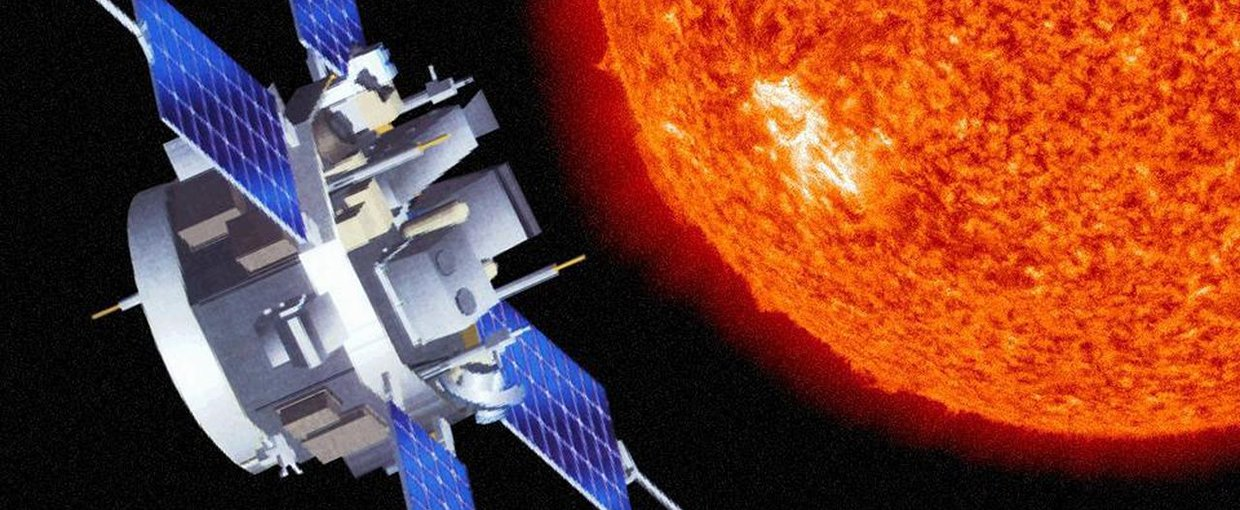

---
**Desenvolvido por:** Rodrigo de Carvalho Andrade  
**Instituição:** Instituto Nacional de Telecomunicações (Inatel) | PFT xGMobile 2026

## 1. O Contexto: A Importância do Clima Espacial

O ambiente fora da atmosfera terrestre não é um vácuo vazio e silencioso. O Sol emite constantemente um fluxo de partículas carregadas conhecido como "Vento Solar". Periodicamente, a estrela libera tempestades violentas chamadas de Ejeções de Massa Coronal (CMEs). Quando essas nuvens de plasma magnetizado atingem a Terra, elas podem causar desde belas auroras até desastres tecnológicos severos, como a queima de satélites de GPS, interrupção de internet e colapsos em redes elétricas continentais.

Para prover um alerta antecipado contra essas ameaças, a Administração Oceânica e Atmosférica Nacional dos EUA (NOAA), em parceria com a NASA, opera o satélite **ACE (Advanced Composition Explorer)**. Posicionado a 1,5 milhão de quilômetros da Terra, ele atua como uma ferramenta de alerta antecipado, medindo a radiação e o campo magnético cerca de uma hora antes de o vento solar atingir o nosso planeta.

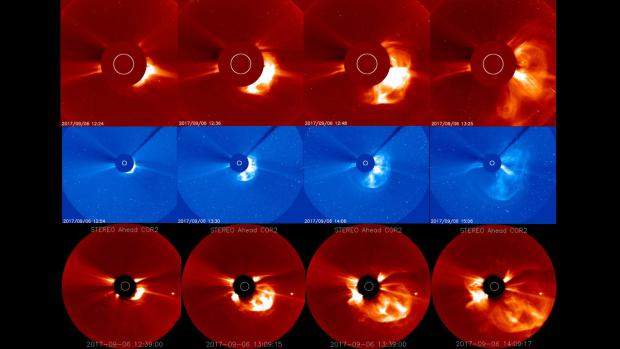

*Ejeção de Massa Coronal registrada pelos instrumentos da NASA. (Crédito: NASA and the SOHO and STEREO missions)*

## 2. A Engenharia de Dados Aplicada

Os instrumentos do satélite transmitem pacotes de telemetria contínuos para a Terra. No entanto, esses dados chegam em estado bruto, em frequências de amostragem incompatíveis e frequentemente com ruídos.

O objetivo deste projeto é construir um **Sistema Adaptativo de Saneamento de Dados (SASD)**. O sistema desenvolvido atua como um funil de saneamento:
1. **Arquitetura Modular:** O código foi projetado em pacotes distintos (Extração, Saneamento, Compilação e Visualização) que interagem entre si, garantindo reuso e manutenibilidade.
2. **Exceções Personalizadas:** Falhas físicas nos sensores são isoladas e tratadas por uma hierarquia de erros customizados.
3. **Processamento Funcional:** A limpeza primária dos arquivos adota mapeamentos em alta ordem (`map` e `filter`) para maior performance.
4. Ao final, os dados são compilados em uma matriz matemática perfeitamente alinhada para uso analítico.

## 3. A Extração de Dados: Classe `NoaaDataExtractor`

O primeiro passo do fluxo (o "E" do conceito ETL - Extract, Transform, Load) é a coleta das informações. A classe `NoaaDataExtractor` foi projetada para atuar como o comunicador do sistema com os servidores da NOAA.

Como o sistema lida com requisições de rede, ele está sujeito a instabilidades, como quedas de internet ou indisponibilidade temporária do servidor americano. Para garantir a resiliência do projeto, implementou-se um encapsulamento com tratamento de exceções (blocos `try/except`). Caso o download de um sensor falhe, o algoritmo registra o erro, protege a execução para que o programa não seja interrompido abruptamente, e segue para a coleta do próximo arquivo.

In [1]:
# Cleans up previously generated modular files to prevent code duplication
# when re-running cells with the 'append' (-a) flag.
!rm -f noaa_extractor.py noaa_sanitizers.py noaa_visualizer.py

In [2]:
%%writefile noaa_extractor.py
import os
import requests

# ==========================================
# PHASE 1 & 2: DATA EXTRACTION MODULE
# ==========================================
class NoaaDataExtractor:
    """
    Manages the extraction of real-time space weather data from NOAA servers.
    Implements network exception handling and file IO operations.
    """
    DEFAULT_FOLDER = "data"

    def __init__(self, sources_dict: dict, output_folder: str = None):
        self.sources = sources_dict
        self.output_folder = output_folder or self.DEFAULT_FOLDER
        self.successes = 0
        self.errors = 0

    @classmethod
    def with_default_sources(cls):
        """Factory method providing a pre-configured instance."""
        default_sources = {
            "ace-epam": "https://services.swpc.noaa.gov/text/ace-epam.txt",
            "ace-sis": "https://services.swpc.noaa.gov/text/ace-sis.txt",
            "ace-mag": "https://services.swpc.noaa.gov/text/ace-magnetometer.txt",
            "ace-swepam": "https://services.swpc.noaa.gov/text/ace-swepam.txt"
        }
        return cls(default_sources)

    def _prepare_directory(self):
        os.makedirs(self.output_folder, exist_ok=True)

    def _download_single_source(self, name: str, url: str):
        file_path = os.path.join(self.output_folder, f"{name}.txt")

        try:
            r = requests.get(url, timeout=15)
            r.raise_for_status()

            with open(file_path, "w", encoding="utf-8") as f:
                f.write(r.text)

            self.successes += 1
            print(f"  -> Extracted {name} successfully.")

        except requests.exceptions.RequestException as net_error:
            print(f"  -> Network exception on {name}: {net_error}")
            self.errors += 1
        except Exception as e:
            print(f"  -> Unexpected IO error on {name}: {e}")
            self.errors += 1

    def extract_all(self):
        self._prepare_directory()
        print(f"Initializing extraction from {len(self.sources)} endpoints...\n" + "-"*60)

        for name, url in self.sources.items():
            self._download_single_source(name, url)

        print(f"Extraction concluded. Success: {self.successes} | Failed: {self.errors}")

Writing noaa_extractor.py


## 4. O Saneamento: POO e Exceções Personalizadas

Com os arquivos salvos localmente, inicia-se a validação semântica. Durante interferências solares, os sensores preenchem a matriz com marcadores de erro estáticos (como `-9999.9`). Se esses valores entrarem em uma análise estatística, as médias e previsões serão severamente distorcidas.

Utilizou-se o paradigma de **Programação Orientada a Objetos (POO)** integrado a um sistema de **Exceções Personalizadas**.

* **Família NOAADataError:** Em vez de usar erros genéricos da linguagem, criou-se exceções de domínio (`InstrumentFailureError` e `OutOfBoundsError`). O sistema sabe diferenciar se um dado quebrou por erro de formatação ou se foi uma anomalia física detectada no espaço.
* **O Descritor de Controle:** A classe `SensorValidator` atua como um "Descritor" (`__get__` e `__set__`). Ela age como uma barreira de segurança contínua: qualquer tentativa de salvar um dado no sistema passa por ela. Se o valor quebrar as leis físicas, a classe levanta a exceção personalizada correspondente e bloqueia o dado.

In [3]:
%%writefile noaa_sanitizers.py
import os
import pandas as pd
from abc import ABC, abstractmethod

# ==========================================
# CUSTOM EXCEPTIONS
# ==========================================
class NOAADataError(Exception):
    """Base exception class for all NOAA pipeline anomalies."""
    pass

class InstrumentFailureError(NOAADataError):
    """Raised when the sensor outputs a known NOAA hardware failure code (e.g., -9999.9)."""
    pass

class OutOfBoundsError(NOAADataError):
    """Raised when data violates the physical boundaries possible for the instrument."""
    pass


# ==========================================
# PHASE 3: OBJECT-ORIENTED ARCHITECTURE BASE
# ==========================================
class SensorValidator:
    """
    Python Descriptor enforcing boundary constraints and custom exception handling.
    Allows None types to pass through, enabling graceful degradation for secondary sensors.
    """
    def __init__(self, min_val: float, max_val: float, error_code: float):
        self.min_val = min_val
        self.max_val = max_val
        self.error_code = error_code
        self.private_name = None

    def __set_name__(self, owner, name):
        # Maps the public attribute name to a private storage variable automatically
        self.private_name = f"_{name}"

    def __get__(self, instance, owner):
        if instance is None:
            return self
        return getattr(instance, self.private_name, None)

    def __set__(self, instance, value):
        # Bypass validation if None, supporting the Graceful Degradation pattern
        if value is None:
            setattr(instance, self.private_name, None)
            return

        try:
            val = float(value)
        except ValueError:
            raise ValueError(f"Value '{value}' must be numeric.")

        # Custom Exception Routing based on business logic
        if val == self.error_code:
            raise InstrumentFailureError(f"NOAA Sensor Flag Detected: {val}")

        if val < self.min_val or val > self.max_val:
            raise OutOfBoundsError(f"Physics Error: {val} is outside allowed range ({self.min_val} to {self.max_val}).")

        setattr(instance, self.private_name, val)


class BaseSanitizer(ABC):
    """Abstract Base Class establishing the architectural contract for all data sanitizers."""
    def __init__(self, raw_row: list):
        self.raw_row = raw_row
        self.is_valid = False

    @abstractmethod
    def calibrate_and_clean(self):
        """Must be implemented by subclasses to handle specific satellite data schemas."""
        pass

    @staticmethod
    def extract_timestamp(year: str, month: str, day: str, hm: str) -> str:
        # Standardizes timestamp format to YYYY-MM-DD HH:MM:SS for future Pandas parsing
        return f"{year}-{month}-{day} {hm[:2]}:{hm[2:]}:00"

Writing noaa_sanitizers.py


## 5. Vento Solar e Plasma: Classe `SwepamSanitizer`

A classe `SwepamSanitizer` processa os dados do instrumento SWEPAM (Solar Wind Electron Proton Alpha Monitor). De forma simplificada, este sensor funciona como o "velocímetro" e o "termômetro" do satélite.

Ele mede a **Velocidade** com que o vento solar viaja (crucial para saber em quanto tempo uma tempestade chegará à Terra), a **Densidade** das partículas (o quão "espessa" é a nuvem de plasma) e a **Temperatura**. O sanitizador garante que os limites físicos sejam respeitados, filtrando anomalias onde o sensor poderia acusar temperaturas fisicamente implausíveis ou o código de erro padrão `-9999.9`.

In [4]:
%%writefile -a noaa_sanitizers.py

class SwepamSanitizer(BaseSanitizer):
    """Sanitizer for the Solar Wind Electron Proton Alpha Monitor dataset."""

    # Descriptors initialized with instrument-specific bounds and error codes
    density = SensorValidator(min_val=0.0, max_val=200.0, error_code=-9999.9)
    speed = SensorValidator(min_val=100.0, max_val=3000.0, error_code=-9999.9)
    temperature = SensorValidator(min_val=1000.0, max_val=1.0e+07, error_code=-100000.0)

    def __init__(self, raw_row):
        super().__init__(raw_row)
        self.timestamp = None

    def calibrate_and_clean(self):
        try:
            # Index 6 represents the instrument's operational status.
            # Values other than '0' indicate uncalibrated or corrupted measurements.
            if self.raw_row[6] != '0':
                return False

            self.timestamp = self.extract_timestamp(self.raw_row[0], self.raw_row[1], self.raw_row[2], self.raw_row[3])

            # Assignment triggers the SensorValidator descriptors
            self.density = self.raw_row[7]
            self.speed = self.raw_row[8]
            self.temperature = self.raw_row[9]

            self.is_valid = True
            return True

        except (ValueError, IndexError, NOAADataError):
            # Gracefully catches both standard structural errors and custom physics anomalies
            self.is_valid = False
            return False

    def to_dict(self):
        if not self.is_valid:
            return None
        return {"Timestamp": self.timestamp, "Density": self.density, "Speed": self.speed, "Temperature": self.temperature}

Appending to noaa_sanitizers.py


## 6. O Escudo Terrestre: Classe `MagSanitizer`

Esta classe processa os dados do Magnetômetro (MAG), que atua como uma bússola altamente sensível no espaço. Sua função é vital, pois a Terra possui o seu próprio campo magnético.

O dado mais importante avaliado aqui é o **componente Bz**. Quando o campo magnético do Sol (Bz) aponta para o sul, ele se conecta diretamente ao campo magnético da Terra (que aponta para o norte). Essa conexão "abre as portas" do nosso escudo protetor, permitindo que a tempestade solar entre na nossa atmosfera e cause danos elétricos. O `MagSanitizer` isola esses vetores, descartando linhas onde as flutuações magnéticas passam do limite esperado para o instrumento.

In [5]:
%%writefile -a noaa_sanitizers.py

class MagSanitizer(BaseSanitizer):
    """Sanitizer for the Magnetometer dataset."""
    bx = SensorValidator(min_val=-500.0, max_val=500.0, error_code=-999.9)
    by = SensorValidator(min_val=-500.0, max_val=500.0, error_code=-999.9)
    bz = SensorValidator(min_val=-500.0, max_val=500.0, error_code=-999.9)
    bt = SensorValidator(min_val=0.0, max_val=500.0, error_code=-999.9)

    def __init__(self, raw_row):
        super().__init__(raw_row)
        self.timestamp = None

    def calibrate_and_clean(self):
        try:
            # Status check for magnetic sensors (Index 6)
            if self.raw_row[6] != '0':
                return False

            self.timestamp = self.extract_timestamp(self.raw_row[0], self.raw_row[1], self.raw_row[2], self.raw_row[3])

            self.bx = self.raw_row[7]
            self.by = self.raw_row[8]
            self.bz = self.raw_row[9]
            self.bt = self.raw_row[10]

            self.is_valid = True
            return True

        except (ValueError, IndexError, NOAADataError):
            self.is_valid = False
            return False

    def to_dict(self):
        if not self.is_valid:
            return None
        return {"Timestamp": self.timestamp, "Bx": self.bx, "By": self.by, "Bz": self.bz, "Bt": self.bt}

Appending to noaa_sanitizers.py


## 7. Espectrometria de Alta Energia: Classe `SisSanitizer`

O instrumento SIS (Solar Isotope Spectrometer) foca nos piores cenários radiológicos. Ele quantifica os prótons de altíssima energia lançados por explosões solares extremas.

A importância dessa extração reside na segurança humana: partículas nesse nível de energia são capazes de penetrar os trajes espaciais e a fuselagem de naves, representando risco biológico severo para astronautas, além de corromper memórias de computadores em satélites comerciais. O sanitizador garante que os volumes desses fluxos não sejam distorcidos por dados falsos do hardware.

In [6]:
%%writefile -a noaa_sanitizers.py

class SisSanitizer(BaseSanitizer):
    """Sanitizer for the Solar Isotope Spectrometer dataset."""
    flux_10 = SensorValidator(min_val=0.0, max_val=1.0e10, error_code=-100000.0)
    flux_30 = SensorValidator(min_val=0.0, max_val=1.0e10, error_code=-100000.0)

    def __init__(self, raw_row):
        super().__init__(raw_row)
        self.timestamp = None

    def calibrate_and_clean(self):
        try:
            # SIS contains independent status columns for different energy channels.
            # Row is only discarded if BOTH critical channels report hardware faults.
            if self.raw_row[6] != '0' and self.raw_row[8] != '0':
                return False

            self.timestamp = self.extract_timestamp(self.raw_row[0], self.raw_row[1], self.raw_row[2], self.raw_row[3])

            self.flux_10 = self.raw_row[7]
            self.flux_30 = self.raw_row[9]

            self.is_valid = True
            return True

        except (ValueError, IndexError, NOAADataError):
            self.is_valid = False
            return False

    def to_dict(self):
        if not self.is_valid:
            return None
        return {"Timestamp": self.timestamp, "Flux_10MeV": self.flux_10, "Flux_30MeV": self.flux_30}

Appending to noaa_sanitizers.py


## 8. Monitoramento de Baixa Energia: Classe `EpamSanitizer`

A classe `EpamSanitizer` processa elétrons e prótons de baixa energia. Historicamente, os aumentos graduais nesse sensor são o primeiro indicador de que uma enorme frente de choque está a caminho do satélite ACE.

Nesta classe, implementou-se um conceito avançado de arquitetura de software conhecido como **Degradação Graciosa (Graceful Degradation)**. Caso o índice de anisotropia apresente falha de leitura (`-1.00`), o código captura a exceção e isola o erro, transformando apenas essa coluna em nula (`None`). Isso impede que a falha de um sensor secundário acabe descartando os valiosos dados principais de elétrons e prótons daquela mesma medição.

In [7]:
%%writefile -a noaa_sanitizers.py

class EpamSanitizer(BaseSanitizer):
    """Sanitizer for the Electron, Proton, and Alpha Monitor dataset."""
    electron_38_53 = SensorValidator(min_val=0.0, max_val=1.0e10, error_code=-100000.0)
    electron_175_315 = SensorValidator(min_val=0.0, max_val=1.0e10, error_code=-100000.0)
    proton_47_68 = SensorValidator(min_val=0.0, max_val=1.0e10, error_code=-100000.0)
    proton_115_195 = SensorValidator(min_val=0.0, max_val=1.0e10, error_code=-100000.0)

    anisotropy_index = SensorValidator(min_val=0.0, max_val=2.0, error_code=-1.0)

    def __init__(self, raw_row):
        super().__init__(raw_row)
        self.timestamp = None

    def calibrate_and_clean(self):
        try:
            # Evaluates status for both Electron (Index 6) and Proton (Index 9) arrays
            if self.raw_row[6] != '0' and self.raw_row[9] != '0':
                return False

            self.timestamp = self.extract_timestamp(self.raw_row[0], self.raw_row[1], self.raw_row[2], self.raw_row[3])

            self.electron_38_53 = self.raw_row[7]
            self.electron_175_315 = self.raw_row[8]
            self.proton_47_68 = self.raw_row[10]
            self.proton_115_195 = self.raw_row[11]

            # Graceful Degradation Pattern:
            # Anisotropy index frequently drops while particle fluxes remain perfectly valid.
            # Catching the NOAADataError locally prevents discarding the entire operational row.
            try:
                self.anisotropy_index = self.raw_row[15]
            except NOAADataError:
                self.anisotropy_index = None

            self.is_valid = True
            return True

        except (ValueError, IndexError, NOAADataError):
            self.is_valid = False
            return False

    def to_dict(self):
        if not self.is_valid:
            return None
        return {
            "Timestamp": self.timestamp,
            "Electron_38_53": self.electron_38_53,
            "Electron_175_315": self.electron_175_315,
            "Proton_47_68": self.proton_47_68,
            "Proton_115_195": self.proton_115_195,
            "Anisotropy_Index": self.anisotropy_index
        }

Appending to noaa_sanitizers.py


## 9. Processamento Funcional e Alinhamento Pandas

Na etapa de roteamento dos dados, evitou-se o uso excessivo de laços de repetição (`for/if`) para tratar strings puras. A classe `NoaaDataPipeline` emprega o paradigma de **Processamento Funcional**, utilizando funções de alta ordem (`filter` e `map`) combinadas com funções anônimas (`lambda`). Isso permite remover cabeçalhos vazios e separar dados brutos de forma imutável, rápida e altamente legível.

Após o roteamento limpo, o maior desafio analítico é resolvido pela classe `NoaaDataCompiler`: a assimetria temporal. O Magnetômetro entrega leituras a cada 1 minuto, enquanto detectores de partículas agrupam dados a cada 5 minutos.

Utilizando a biblioteca **Pandas**, aplicou-se a interpolação `.resample('5min').mean()` para criar uma janela matemática deslizante. O algoritmo calcula a média exata dentro daquele intervalo e cria um índice de tempo padronizado (o `master_df`), onde cada linha representa exatamente uma "fotografia" sincronizada de todos os sistemas do satélite, pronta para consumo por modelos de Inteligência Artificial.

In [8]:
%%writefile -a noaa_sanitizers.py

class NoaaDataPipeline:
    """Automates the ingestion and routing of raw files to specific OOP sanitizers."""
    def __init__(self, data_folder: str):
        self.data_folder = data_folder

        # Factory Map: Links raw dataset names to their respective Sanitizer classes
        self.sanitizer_map = {
            "ace-swepam": SwepamSanitizer,
            "ace-mag": MagSanitizer,
            "ace-sis": SisSanitizer,
            "ace-epam": EpamSanitizer
        }
        self.clean_datasets = {}

    def run_pipeline(self) -> dict:
        print("\nInitiating Data Sanitization Pipeline...\n" + "-"*60)

        for source_name, SanitizerClass in self.sanitizer_map.items():
            file_path = os.path.join(self.data_folder, f"{source_name}.txt")

            if not os.path.exists(file_path):
                continue

            clean_rows = []
            with open(file_path, "r", encoding="utf-8") as file:
                raw_lines = file.readlines()

                # Filter + Lambda: Removes headers, metadata, and empty line breaks
                valid_lines = filter(
                    lambda line: line.strip() and not line.startswith(("#", ":")),
                    raw_lines
                )

                # Map + Lambda: Transforms the surviving strings into lists of values
                parsed_rows = map(lambda line: line.split(), valid_lines)

                # Iterates over the functionally processed elements
                for row_list in parsed_rows:
                    # Instantiates dynamically based on the current loop iteration
                    sanitizer_instance = SanitizerClass(row_list)
                    sanitizer_instance.calibrate_and_clean()

                    data_dict = sanitizer_instance.to_dict()
                    if data_dict is not None:
                        clean_rows.append(data_dict)

            self.clean_datasets[source_name] = clean_rows
            print(f"[{source_name.upper()}] Verified and extracted {len(clean_rows)} valid records.")

        print("-" * 60)
        return self.clean_datasets


# ==========================================
# PHASE 4: DATA INTEGRATION (PANDAS)
# ==========================================
class NoaaDataCompiler:
    """Consolidates independent datasets into a unified multivariate Time-Series DataFrame."""
    def __init__(self, raw_datasets: dict):
        self.raw_datasets = raw_datasets
        self.master_df = None

    def compile_to_dataframe(self) -> pd.DataFrame:
        dataframes = []

        for source, data_list in self.raw_datasets.items():
            if not data_list:
                continue

            df = pd.DataFrame(data_list)

            # Explicit formatting significantly improves Datetime parsing performance
            df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y-%m-%d %H:%M:%S')
            df.set_index('Timestamp', inplace=True)

            numeric_cols = df.select_dtypes(include='number').columns

            # Mathematical aggregation resolving sampling asymmetry (e.g., MAG 1-min vs SWEPAM 5-min)
            df_resampled = df[numeric_cols].resample('5min').mean()
            dataframes.append(df_resampled)

        if not dataframes:
            return None

        # Horizontally aligns all instruments based on the synchronized DatetimeIndex
        self.master_df = pd.concat(dataframes, axis=1)

        # Drops rows where all instrument readings are missing
        self.master_df.dropna(how='all', inplace=True)

        return self.master_df

Appending to noaa_sanitizers.py


## 10. Dashboard de Decisão Visual e Validação Oficial

Por fim, o volume massivo de dados numéricos consolidados é traduzido graficamente por meio da biblioteca `Matplotlib`.

A disposição da classe visualizadora `NoaaDashboardVisualizer` respeita rigorosamente o rigor científico. Em vez de interpolar ou criar linhas artificiais para cobrir falhas momentâneas do satélite ACE, o código preserva a integridade visual da ausência (`NaN`), refletindo com precisão o status real do equipamento em órbita. As cores, os agrupamentos e as escalas logarítmicas (necessárias para ilustrar saltos exponenciais na contagem de partículas) foram ajustadas para facilitar a interpretação técnica.

**Validação de Resultados:**
Os painéis gerados automaticamente por este software podem ser comparados diretamente com o painel oficial do governo americano, disponível no portal da NOAA em:
[https://www.swpc.noaa.gov/products/ace-real-time-solar-wind](https://www.swpc.noaa.gov/products/ace-real-time-solar-wind)

*Nota: Os gráficos gerados pela execução do código podem apresentar ligeiras variações visuais em relação ao site oficial devido à unificação matemática baseada em intervalos estritos de amostragem de 5 minutos, e pela adaptação autônoma dos eixos limitadores dinâmicos calculados pelo Matplotlib.*

In [9]:
%%writefile noaa_visualizer.py
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

# ==========================================
# PHASE 4: VISUAL ANALYTICS MODULE
# ==========================================
class NoaaDashboardVisualizer:
    """
    Constructs high-fidelity analytical dashboards mirroring official NOAA RTSW systems.
    Maintains scientific rigor by natively representing NaN segments without interpolation.
    """
    def __init__(self, dataframe: pd.DataFrame):
        self.df = dataframe.copy()

        numeric_cols = [
            'Speed', 'Density', 'Temperature', 'Bt', 'Bz',
            'Electron_38_53', 'Electron_175_315', 'Proton_47_68', 'Proton_115_195'
        ]

        # Explicit coercion prevents Matplotlib rendering deadlocks caused by stray string objects
        for col in numeric_cols:
            if col in self.df.columns:
                self.df[col] = pd.to_numeric(self.df[col], errors='coerce')

    def _setup_axis_grid(self, ax):
        """Standardizes background grid and forces timestamp visibility across shared subplots."""
        ax.grid(True, color='gray', linestyle=':', alpha=0.5)
        ax.tick_params(axis='x', rotation=0, labelbottom=True)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
        ax.set_xlabel('UTC Time', fontsize=10, fontweight='bold')

    def plot_mag_swepam_dashboard(self):
        """Renders the primary Solar Wind & Magnetic Field interface."""
        if self.df.empty:
            return

        plt.style.use('dark_background')
        fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=True)
        fig.suptitle('ACE REAL-TIME SOLAR WIND (MAG & SWEPAM)',
                     fontsize=18, fontweight='bold', color='cornflowerblue', x=0.1, ha='left')

        ax_mag, ax_density, ax_speed, ax_temp = axes

        if {'Bt', 'Bz'}.issubset(self.df.columns):
            ax_mag.plot(self.df.index, self.df['Bt'], color='white', linewidth=1.5, label='Bt')
            ax_mag.plot(self.df.index, self.df['Bz'], color='red', linestyle='--', linewidth=1.5, label='Bz')
            ax_mag.axhline(0, color='gray', linestyle='--', linewidth=1)
            ax_mag.set_ylabel('Bt, Bz\n(nT)', color='white', fontweight='bold')
            ax_mag.legend(loc='upper left', frameon=False, ncol=2)

        # Logarithmic scales are applied where exponential fluctuations are standard phenomena
        if 'Density' in self.df.columns:
            ax_density.plot(self.df.index, self.df['Density'], color='orange', linewidth=1.5)
            ax_density.set_ylabel('Density\n(p/cm³)', color='orange', fontweight='bold')
            ax_density.set_yscale('log')

        if 'Speed' in self.df.columns:
            ax_speed.plot(self.df.index, self.df['Speed'], color='yellow', linewidth=1.5)
            ax_speed.set_ylabel('Speed\n(km/s)', color='yellow', fontweight='bold')

        if 'Temperature' in self.df.columns:
            ax_temp.plot(self.df.index, self.df['Temperature'], color='lime', linewidth=1.5)
            ax_temp.set_ylabel('Temp\n(K)', color='lime', fontweight='bold')
            ax_temp.set_yscale('log')

        for ax in axes:
            self._setup_axis_grid(ax)

        plt.tight_layout()
        plt.subplots_adjust(top=0.93, hspace=0.35)
        plt.show()

    def plot_epam_particles(self):
        """Renders the secondary high-energy particle flux interface."""
        if self.df.empty:
            return

        plt.style.use('dark_background')
        fig, (ax_elec, ax_prot) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)
        fig.suptitle('ACE RTSW EPAM PARTICLES',
                     fontsize=18, fontweight='bold', color='cornflowerblue', x=0.1, ha='left')

        if {'Electron_38_53', 'Electron_175_315'}.issubset(self.df.columns):
            ax_elec.plot(self.df.index, self.df['Electron_38_53'], color='lime', label='38-53 keV')
            ax_elec.plot(self.df.index, self.df['Electron_175_315'], color='cyan', label='175-315 keV')
            ax_elec.set_ylabel('Electrons\nFlux', color='cyan', fontweight='bold')
            ax_elec.set_yscale('log')
            ax_elec.legend(loc='upper left', frameon=False, ncol=2)

        if {'Proton_47_68', 'Proton_115_195'}.issubset(self.df.columns):
            ax_prot.plot(self.df.index, self.df['Proton_47_68'], color='red', label='47-68 keV')
            ax_prot.plot(self.df.index, self.df['Proton_115_195'], color='orange', label='115-195 keV')
            ax_prot.set_ylabel('Protons\nFlux', color='orange', fontweight='bold')
            ax_prot.set_yscale('log')
            ax_prot.legend(loc='upper left', frameon=False, ncol=2)

        for ax in [ax_elec, ax_prot]:
            self._setup_axis_grid(ax)

        plt.tight_layout()
        plt.subplots_adjust(top=0.90, hspace=0.35)
        plt.show()

        # Resets Matplotlib global style settings to avoid polluting downstream notebook cells
        plt.style.use('default')

Writing noaa_visualizer.py


**Execução Modular:**
O bloco de código final a seguir demonstra a prova de arquitetura do sistema. Em vez de operar em um script monolítico, a execução importa as classes dos módulos `.py` gerados ao longo do notebook.

Initializing extraction from 4 endpoints...
------------------------------------------------------------
  -> Extracted ace-epam successfully.
  -> Extracted ace-sis successfully.
  -> Extracted ace-mag successfully.
  -> Extracted ace-swepam successfully.
Extraction concluded. Success: 4 | Failed: 0

Initiating Data Sanitization Pipeline...
------------------------------------------------------------
[ACE-SWEPAM] Verified and extracted 92 valid records.
[ACE-MAG] Verified and extracted 115 valid records.
[ACE-SIS] Verified and extracted 23 valid records.
[ACE-EPAM] Verified and extracted 23 valid records.
------------------------------------------------------------

Aligning Time-Series via Pandas Interpolation...
------------------------------------------------------------
Data Matrix structured successfully. Final Architecture:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 24 entries, 2026-04-14 00:20:00 to 2026-04-14 02:15:00
Freq: 5min
Data columns (total 13 columns):
 #   

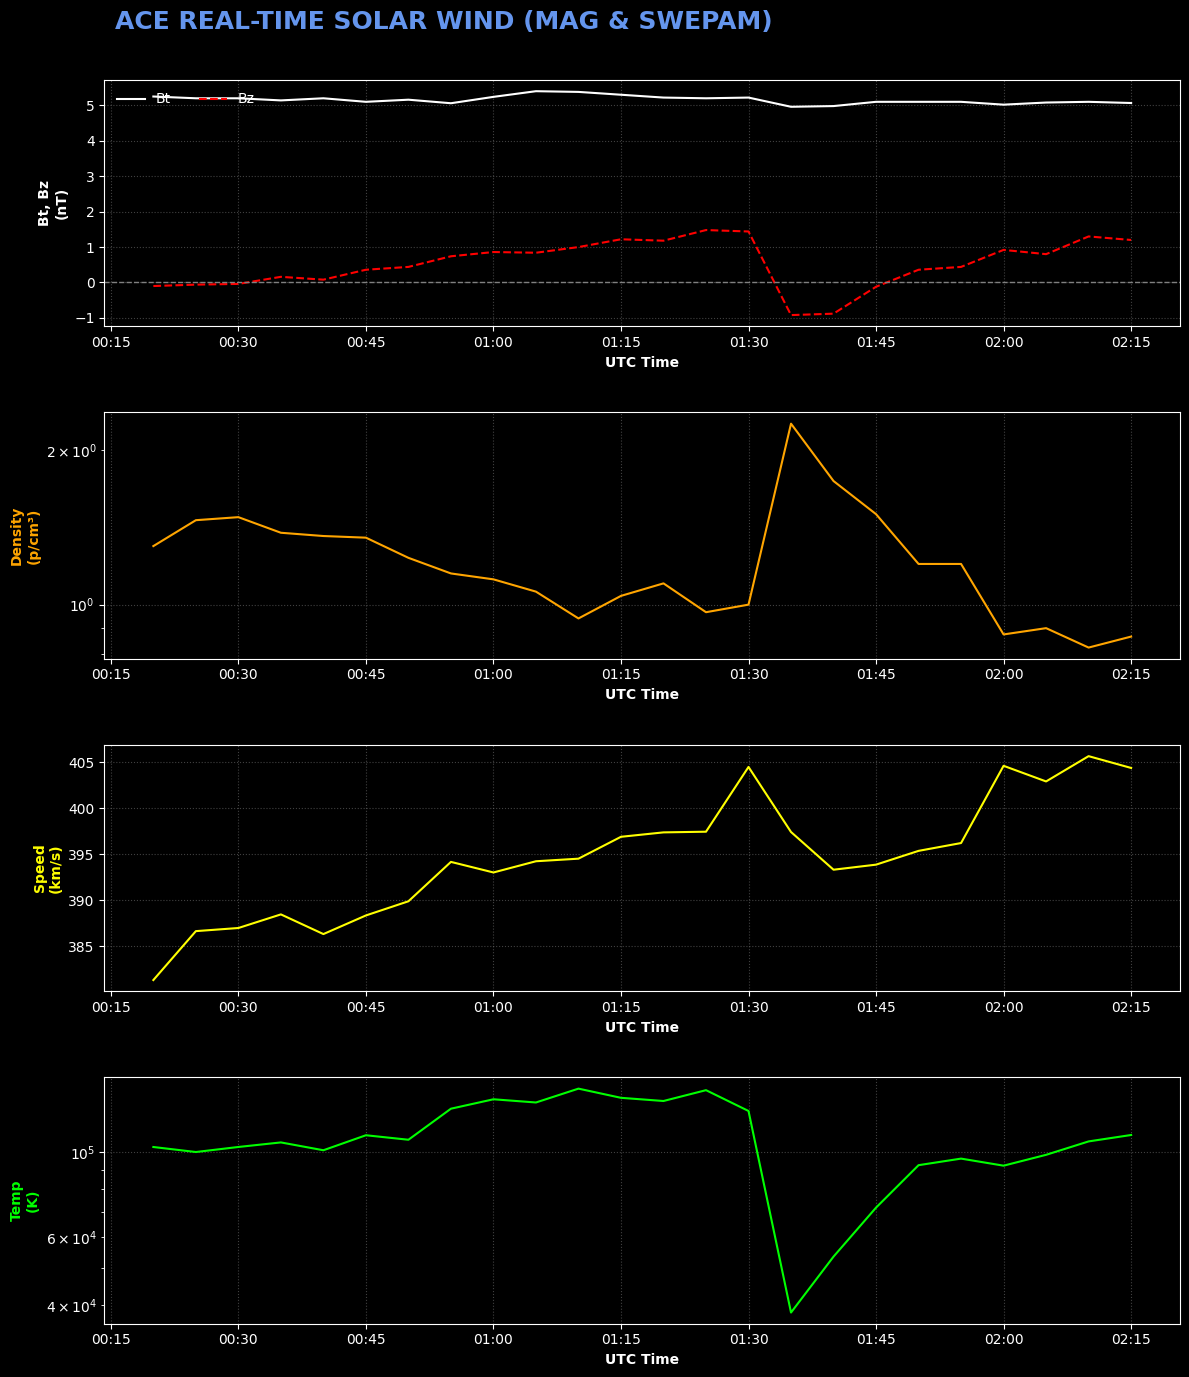

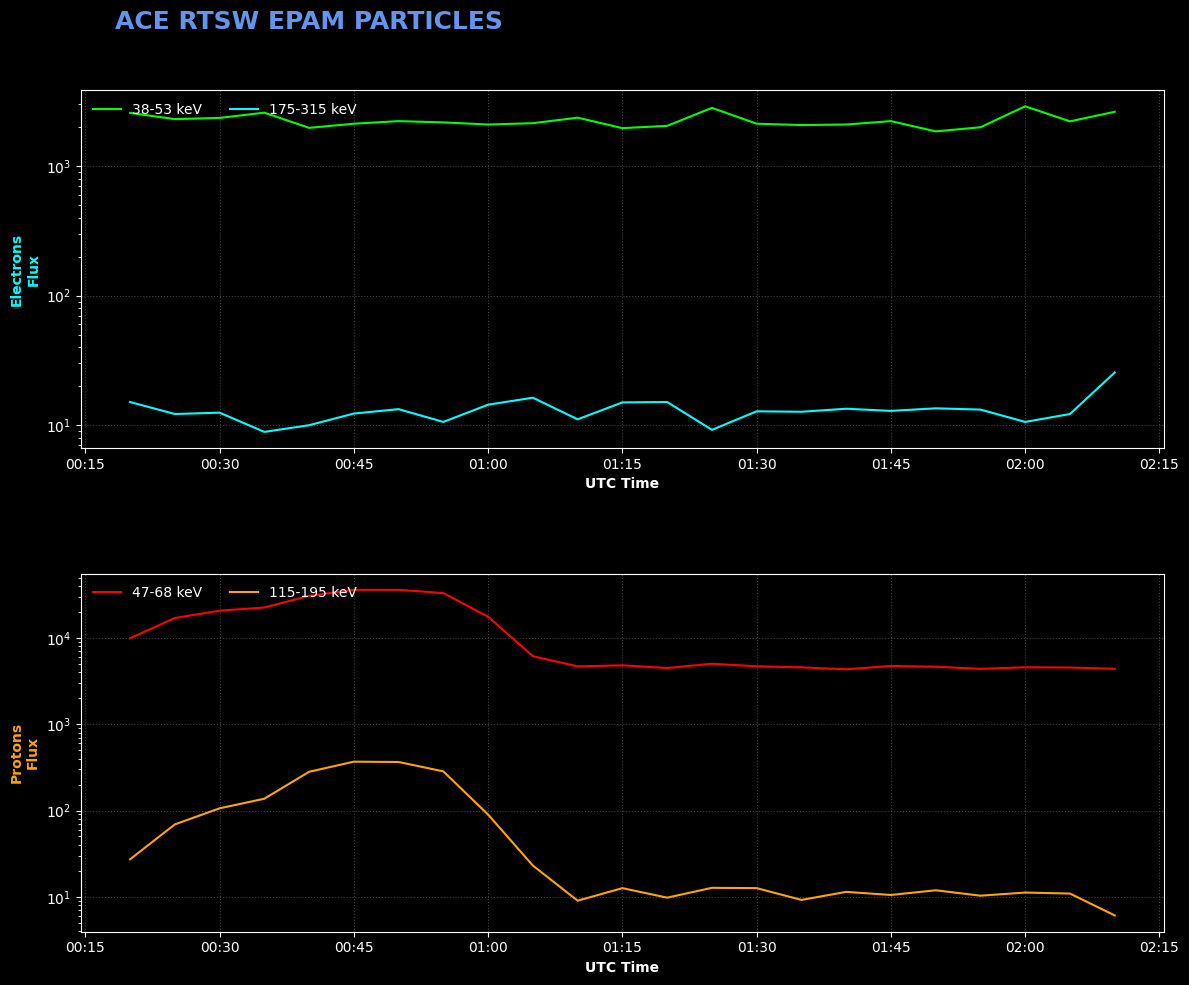

In [10]:
# ==========================================
# MAIN EXECUTION THREAD (MODULAR ARCHITECTURE)
# ==========================================
# Imports the components from the modular files generated within the Colab workspace
from noaa_extractor import NoaaDataExtractor
from noaa_sanitizers import NoaaDataPipeline, NoaaDataCompiler
from noaa_visualizer import NoaaDashboardVisualizer

if __name__ == "__main__":

    # Required for inline plot rendering within the Jupyter/Colab environment
    get_ipython().run_line_magic('matplotlib', 'inline')

    # 1. Pipeline Initiation (Extraction)
    extractor = NoaaDataExtractor.with_default_sources()
    extractor.extract_all()

    # 2. Application of Quality Control Rules (OOP & Functional Routing)
    pipeline = NoaaDataPipeline("data")
    final_data = pipeline.run_pipeline()

    # 3. Consolidation into Predictive Matrices
    print("\nAligning Time-Series via Pandas Interpolation...\n" + "-"*60)
    compiler = NoaaDataCompiler(final_data)
    master_df = compiler.compile_to_dataframe()

    if master_df is not None:
        print("Data Matrix structured successfully. Final Architecture:")
        print(master_df.info())
        print("-" * 60)

        # 4. Final Analytical Delivery
        visualizer = NoaaDashboardVisualizer(master_df)
        visualizer.plot_mag_swepam_dashboard()
        visualizer.plot_epam_particles()